Esercizi con DBSCAN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans

In [5]:
# caricamento del dataset con n_samples=400, noise=0.07, factor=0.5 e random_state=42

X, y = make_moons(n_samples=400, noise=0.07, random_state=42)
print(f"X shape: {X.shape}\ny shape: {y.shape}")


X shape: (400, 2)
y shape: (400,)


In [6]:
# Standardizzazione dei dati
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

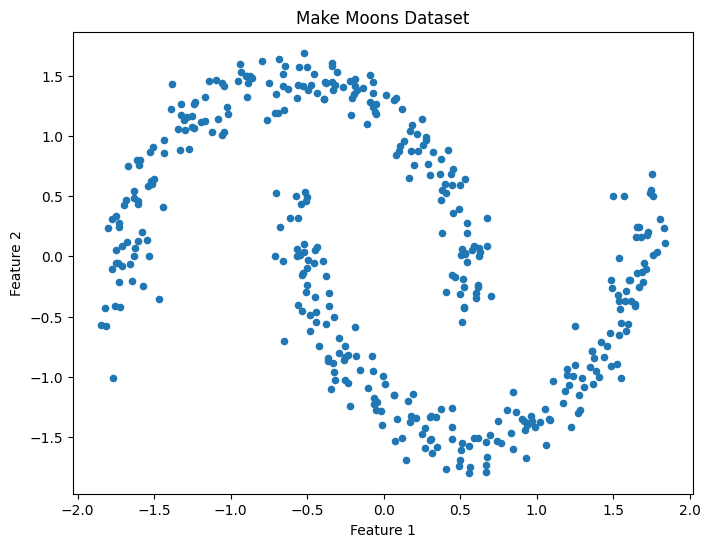

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=20)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Make Moons Dataset")
plt.show()

# abbiamo scelto questo db perché è l'esempio di dati che non hanno funzioni lineari tra loro

In [9]:
eps = 0.2
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X_scaled)
labels = dbscan.labels_

In [10]:
# calcoliamo il numero di cluster escludendo i rumori (label -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Found clusters: {n_clusters}")

Found clusters: 3


In [11]:
# vediamo quanti punti sono stati assegnati ai cluster e quanti al rumore
assingned = np.sum(labels != -1)
tot = len(labels)
noise = tot - assingned
print(f"Assigned: {assingned}\nNoise: {noise}\nPercentage assigned: {assingned/tot *100:.2f}%")

Assigned: 397
Noise: 3
Percentage assigned: 99.25%


<>:16: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:16: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
C:\Users\chian\AppData\Local\Temp\ipykernel_23328\2504109461.py:16: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  plt.title(f"DBSCAN Clustering\n$eps = {eps}$, $min\_samples = {min_samples}$")
C:\Users\chian\AppData\Local\Temp\ipykernel_23328\2504109461.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points

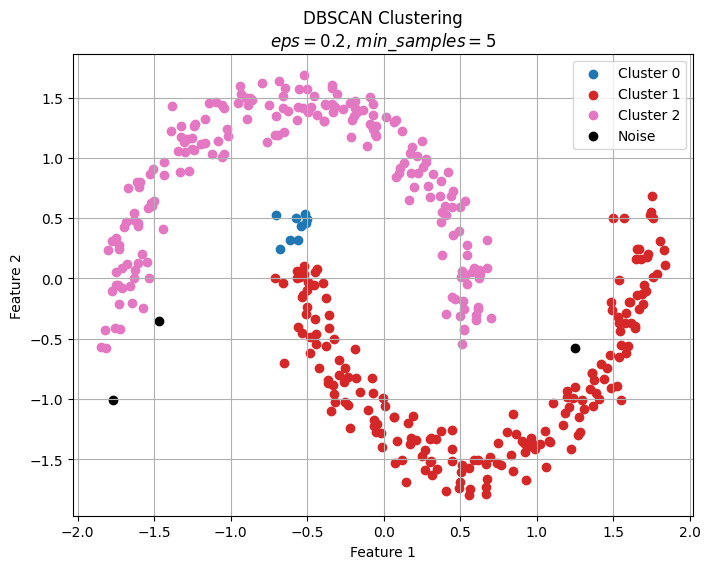

In [13]:
# rappresentazione grafica dei cluster trovati
plt.figure(figsize=(8,6))
# abbiamo fatto due liste della stessa lunghezza, una per le label e una per i colori
unique_labels = set(labels)
colors = [plt.cm.tab10(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == - 1:
        col = [0, 0, 0, 1]  # nero per il rumore
    class_member_mask = (labels == k)
    xy = X_scaled[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=(col), label=f"Cluster {k}" if k != -1 else "Noise")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"DBSCAN Clustering\n$eps = {eps}$, $min\_samples = {min_samples}$")
plt.legend()
plt.grid()
plt.show()

In [14]:
# facciamo cluster con Kmeans per vedere la differenza nel caso di un dataset non lineare
kmeans = KMeans(n_clusters=n_clusters, init="k-means++", random_state=42)
clusters = kmeans.fit_predict(X)


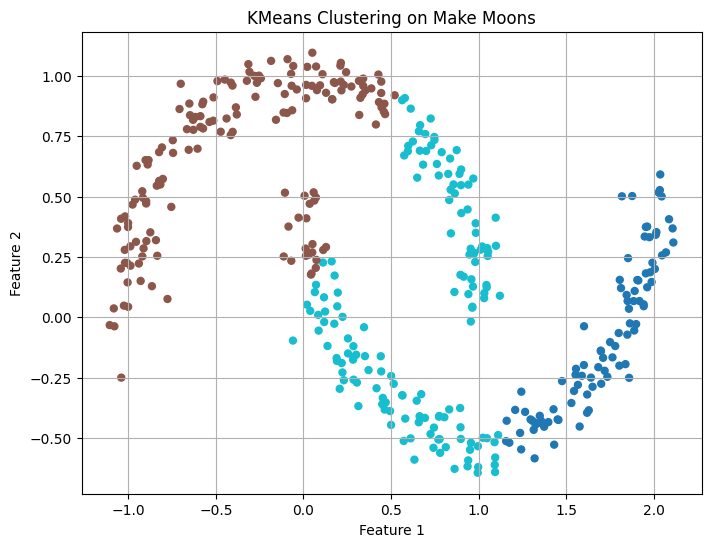

In [15]:
plt.figure(figsize=(8,6))
plt.title("KMeans Clustering on Make Moons")
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="tab10", s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.show()